# Stage 03 — the sensor sweep: one recipe, several runs

Stage 02 submitted and rendered one run, `manifold_run_specs/auror_ref.yaml`, with one sensor. This
notebook keeps that scenario (scene, platform position, atmosphere, epoch, seed) and changes the
sensor. It shows where a sensor is described, what a run's `.platform` is built from, and how one
recipe becomes one run per sensor:

1. **The sensor library.** `manifold_sensors/` holds one `sensor-spec/1` document per sensor system. The
   spectral curves those documents reference live under `manifold_sensors/spectral/`.
2. **What DIRSIG sees.** `protodirsig.platform_gen` renders a run's `.platform` from the library
   template, the sensor-spec and the run spec's `settings`. Each channel becomes one tabulated
   response: the product of the optics curve, the channel shape and the QE curve.
3. **A sweep recipe.** `manifold_run_specs/recipes/sensor_sweep_tahoe.yaml` lists the three library
   sensors with one scenario and one engine profile. `compose.compose_sweep` composes one run spec per
   sensor, and `LocalRegistry.submit_sweep` accepts or rejects each with the same three checks as Stage 02.
   There is no run-time sensor override: each run spec describes its own run (CONOPS and Guide, §3.5, C-18).
4. **Three renders.** `LocalRegistry.run_sweep` renders every accepted run. The recipe models a 32 × 32
   window per sensor, so each render takes seconds. Then the ground sample distance of each, measured
   from DIRSIG's geolocation truth.

The library's one-run specs model 500 × 500 pixels, which takes about 7 minutes per render. The sensor
model, its units and the measurements behind it are in the CONOPS and Guide, sections 4 and 9.

---
# Setup

## Environment

From a fresh clone, run `python scripts/bootstrap.py install` once. It links the DIRSIG installation
as `external/dirsig` and checks out (or links) `dirfm` as `external/dirsig-file-maker`. This cell
uses `DIRSIG_HOME` if it is set, and `external/dirsig` otherwise, and puts its `bin/` on `PATH`.
`dirfm` is imported from the environment if it is installed there, and from `external/` if not.
`protodirsig` comes from `src/`. Everything the notebook writes goes under `outputs/stage_03_sweep/`.

In [1]:
import os
import shutil
import sys
from pathlib import Path

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXTERNAL = PROJECT / "external"                       # populated by scripts/bootstrap.py install
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME") or EXTERNAL / "dirsig").resolve()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), \
    "DIRSIG binaries not on PATH: set DIRSIG_HOME or run scripts/bootstrap.py install"

try:
    import dirfm
except ImportError:
    sys.path.insert(0, str(EXTERNAL / "dirsig-file-maker"))
    import dirfm
try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig

RUN_SPEC = PROJECT / "manifold_run_specs" / "auror_ref.yaml"
RECIPE = PROJECT / "manifold_run_specs" / "recipes" / "sensor_sweep_tahoe.yaml"   # the sweep
CONFIG_REPO = PROJECT / "manifold_config_repo"                 # engine assets, read-only
LIB = PROJECT / "manifold_sensors"                             # sensor library, read-only
WORK = PROJECT / "outputs" / "stage_03_sweep"
if WORK.exists():
    shutil.rmtree(WORK)                               # our own directory
WORK.mkdir(parents=True)
print("DIRSIG_HOME :", DIRSIG_HOME)
print("dirfm       :", Path(dirfm.__file__).parent)
print("run spec    :", RUN_SPEC.relative_to(PROJECT))
print("recipe      :", RECIPE.relative_to(PROJECT))
print("libraries   :", CONFIG_REPO.relative_to(PROJECT), LIB.relative_to(PROJECT))

DIRSIG_HOME : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
dirfm       : /home/kevin-kearney/dev/dirsig-file-maker/dirfm
run spec    : manifold_run_specs/auror_ref.yaml
recipe      : manifold_run_specs/recipes/sensor_sweep_tahoe.yaml
libraries   : manifold_config_repo manifold_sensors


---
# Stage 0 — The sensor library

## What is in it

Each `manifold_sensors/<name>.yaml` is a `sensor-spec/1` document: `meta` (name, tags, description) and
`sensor`, the same block a run spec's `descriptor.sensor` would carry inline. A run spec refers to one
by name and hash, `descriptor.sensor.ref: {name: auror-nir.yaml, content_hash: "sha256:…"}`, and the
name resolves against `manifold_sensors/`. The table reads the documents themselves. A value nobody recorded is
`null` in the file and shows as `None`.

In [2]:
import yaml
from protodirsig.run_spec import load_sensor_spec

SENSORS = {}
print(f"{'file':34s} {'vendor / model':30s} {'D mm':>5s} {'f mm':>5s} {'f/#':>4s} {'pitch um':>8s} "
      f"{'full frame':>11s}  channel")
for path in sorted(LIB.glob("*.yaml")):
    doc = load_sensor_spec(LIB, path.name)
    e = doc["sensor"]["entries"][0]
    fp, o = e["focal_planes"][0], e["optics"]
    det, ch = fp["detector"], fp["channels"][0]
    SENSORS[path.name] = (e["entry_id"], doc)
    shape = ch.get("srf_model") or {"kind": "curve"}
    frame = f"{det['SensorWidth']} x {det['SensorHeight']}"
    print(f"{path.name:34s} {str(det['DeviceVendorName']) + ' / ' + str(det['DeviceModelName']):30s} "
          f"{o['aperture_diameter']:5.0f} {o['focal_length']:5.0f} {o['f_number']:4.1f} {det['SensorPixelWidth']:8.1f} "
          f"{frame:>11s}  {ch['channel_id']} {shape['kind']} {ch['band_center']} um, "
          f"{'QE curve' if 'qe_reference' in ch else 'no QE (unit)'}, "
          f"{'optics curve' if 'throughput_reference' in o else 'scalar optics ' + str(o['throughput_in_band']['value'])}")
BY_ENTRY = {entry_id: doc["sensor"]["entries"][0] for entry_id, doc in SENSORS.values()}

file                               vendor / model                  D mm  f mm  f/# pitch um  full frame  channel
auror-nir.yaml                     None / None                       85   306  3.6     10.0 None x None  nir-b1 gaussian 0.85 um, no QE (unit), scalar optics 0.875
deepscan_850_306_nir_1280.yaml     Teledyne / SCION                  85   306  3.6     10.0 1280 x 1024  nir-b1 gaussian 0.85 um, QE curve, scalar optics 0.875
synthetic_600_200_vis_1920.yaml    synthetic / synthetic-cmos-1920x1080    50   200  4.0      5.5 1920 x 1080  vis-pan rectangular 0.6 um, QE curve, optics curve


## One entry, block by block

`synthetic_600_200_vis_1920.yaml` is an invented VIS camera: no vendor, no product. It exists to
exercise every part of the model with values that differ from the AUROR sensor. Its sensor entry
has three blocks the generator reads:

* `optics`: aperture and focal length in millimetres, f-number, in-band throughput, and a reference
  to an optics transmission curve.
* `focal_planes[0].detector`: the physical device. That is the full frame and pixel pitch, in SFNC
  names (`SensorWidth`, `SensorPixelWidth`, …), plus the fill factor. The window DIRSIG models is
  *not* here. It is the commanded `roi` in the run spec's `settings`.
* `focal_planes[0].channels[]`: one entry per band. Each has a shape (`srf_model`: `gaussian` or
  `rectangular`, peak 1, or a filter curve as `srf_reference`) and an optional `qe_reference`, the
  detector's absolute quantum efficiency. Curve references are `{name, content_hash}`. The hash is the
  sha256 of the file's bytes, and the loader checks it. `radiometric_reference` is the sensor's own
  calibration, for example DN to spectral radiance. None is known for these sensors, so its members are
  `null`. What an image pixel holds is a property of the engine, not of the sensor: for DIRSIG it is
  photo-electrons per m² of focal plane over the exposure (CONOPS and Guide, section 9).

In [3]:
VIS_FILE = "synthetic_600_200_vis_1920.yaml"
vis_entry = SENSORS[VIS_FILE][1]["sensor"]["entries"][0]
fp = vis_entry["focal_planes"][0]
for title, block in (("optics", vis_entry["optics"]), ("detector", fp["detector"]),
                     ("readout", fp["readout"]), ("channels[0]", fp["channels"][0])):
    print(f"--- {title}")
    print(yaml.safe_dump(block, sort_keys=False, width=120).rstrip())

--- optics
aperture_diameter: 50.0
focal_length: 200.0
f_number: 4.0
throughput_in_band:
  value: 0.92
  provenance: derived
throughput_reference:
  name: spectral/optics/synthetic_vis_lens.csv
  content_hash: sha256:088dc8fa5c2b4e9b321f976237db9245f14e49b0b43f7b9d92b707073998126b
distortion:
  model: none
--- detector
DeviceVendorName: synthetic
DeviceModelName: synthetic-cmos-1920x1080
SensorWidth: 1920
SensorHeight: 1080
SensorPixelWidth: 5.5
SensorPixelHeight: 5.5
fill_factor: 1.0
channel_layout: single
--- readout
timestamp_reference: exposure_start
SensorShutterMode: Global
AdcBitDepth: 12
--- channels[0]
channel_id: vis-pan
band: VIS
band_center: 0.6
bandwidth: 0.3
srf_model:
  kind: rectangular
  center: 0.6
  width: 0.3
qe_reference:
  name: spectral/qe/synthetic_silicon.csv
  content_hash: sha256:37bf797fdc0376db6bbad16b6c15dbb90bc0dd5e6e6de197f227b89fbca4c049
qe_peak:
  value: 0.9
  provenance: derived
radiometric_reference:
  quantity: null
  unit: null


## The spectral curves

Curves are `spectral-curve/1` CSV files: `#` metadata lines, then wavelength in µm and the value.
`provenance` says where the numbers came from. All three curves in the library today are
**synthetic**: shaped like the real thing, but not vendor data or measurements. Each is zero
outside its stated support, written out as data over 0.150–14.000 µm. Nothing is extrapolated.
Real vendor or measured curves come in through `scripts/import_curve.py` (`manifold_sensors/spectral/README.md`).

spectral/optics/synthetic_vis_lens.csv: transmission, provenance synthetic, range 0.150 14.000 um, 13851 rows, max 0.94
spectral/qe/synthetic_silicon.csv: qe_absolute, provenance synthetic, range 0.150 14.000 um, 13851 rows, max 0.90
spectral/qe/synthetic_visgaas.csv: qe_absolute, provenance synthetic, range 0.150 14.000 um, 13851 rows, max 0.80


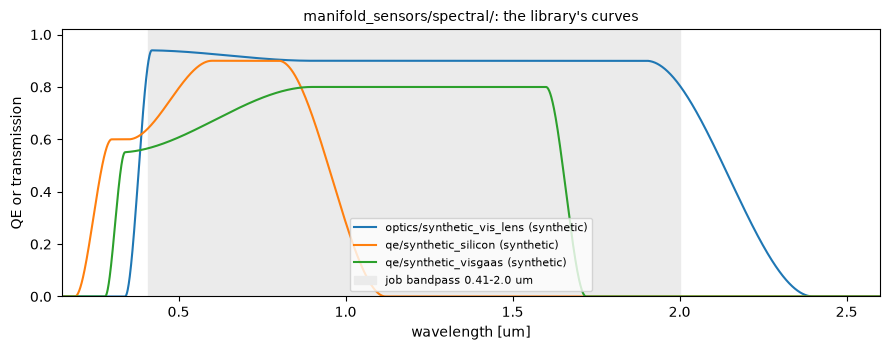

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from protodirsig.spectral import read_curve

fig, ax = plt.subplots(figsize=(9, 3.6))
for path in sorted((LIB / "spectral").glob("*/*.csv")):
    cv = read_curve(path)
    print(f"{path.relative_to(LIB)}: {cv.meta['quantity']}, provenance {cv.meta['provenance']}, "
          f"range {cv.meta['range_um']} um, {len(cv.wavelength)} rows, max {cv.value.max():.2f}")
    ax.plot(cv.wavelength, cv.value, label=f"{path.parent.name}/{path.stem} ({cv.meta['provenance']})")
ax.axvspan(0.41, 2.0, color="0.92", zorder=0, label="job bandpass 0.41-2.0 um")
ax.set_xlim(0.15, 2.6); ax.set_ylim(0, 1.02)
ax.set_xlabel("wavelength [um]"); ax.set_ylabel("QE or transmission")
ax.legend(fontsize=8, loc="lower center"); ax.set_title("manifold_sensors/spectral/: the library's curves", fontsize=10)
plt.tight_layout(); plt.show()

## What DIRSIG sees: the composed channel response

DIRSIG takes one response per channel. The generator renders each library sensor into the
template `.platform` (`manifold_config_repo/platforms/AurorNIRDetector/`). It writes the product of the
three factors as a tabulated channel on the template's 0.41–2.0 µm, 1 nm bandpass grid, with peak
QE in electrons per photon. A scalar optics throughput is not in the channel. It goes to DIRSIG's
`aperturethroughput`, so the plot multiplies it back in to show each sensor's whole spectral chain.

auror-nir                    channel 'nir-b1', shape tabulated, aperturethroughput 0.875, peak 0.875, integral 0.1397 um
deepscan-850-306-nir-1280    channel 'nir-b1', shape tabulated, aperturethroughput 0.875, peak 0.695, integral 0.1102 um


synthetic-600-200-vis-1920   channel 'vis-pan', shape tabulated, aperturethroughput 1, peak 0.834, integral 0.2392 um


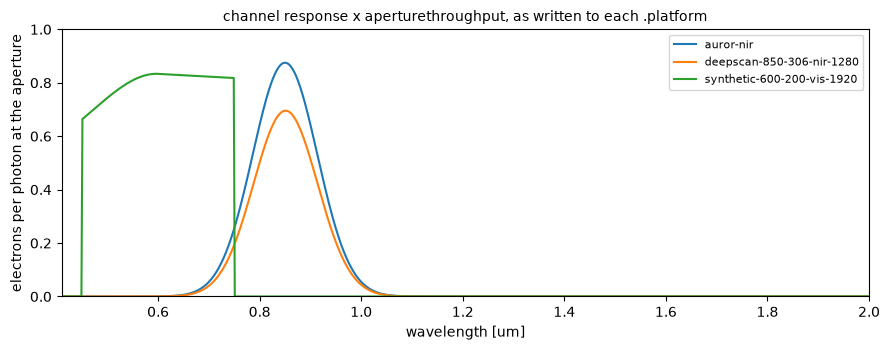

In [5]:
import lxml.etree as et
from protodirsig.platform_gen import render_platform
from protodirsig.run_spec import load_run_spec

TEMPLATE = CONFIG_REPO / "platforms" / "AurorNIRDetector" / "AurorNIRDetector.platform"
base_settings = load_run_spec(RUN_SPEC)["descriptor"]["settings"][0]
fig, ax = plt.subplots(figsize=(9, 3.6))
for name, (entry_id, doc) in SENSORS.items():
    out = render_platform(TEMPLATE, doc, entry_id, [{**base_settings, "entry_id": entry_id}], 10, LIB,
                          WORK / "platforms" / f"{entry_id}.platform")
    root = et.parse(str(out.path)).getroot()
    tau = float(root.findtext(".//properties/aperturethroughput"))
    ch = root.find(".//channellist/channel")
    wl = np.array([float(e.findtext("spectralpoint")) for e in ch.findall("entry")])
    resp = np.array([float(e.findtext("value")) for e in ch.findall("entry")])
    print(f"{entry_id:28s} channel {ch.get('name')!r}, shape {ch.get('shape')}, aperturethroughput {tau:g}, "
          f"peak {resp.max() * tau:.3f}, integral {np.trapezoid(resp * tau, wl):.4f} um")
    ax.plot(wl, resp * tau, label=entry_id)
ax.set_xlim(0.41, 2.0); ax.set_ylim(0, 1)
ax.set_xlabel("wavelength [um]"); ax.set_ylabel("electrons per photon at the aperture")
ax.legend(fontsize=8); ax.set_title("channel response x aperturethroughput, as written to each .platform", fontsize=10)
plt.tight_layout(); plt.show()

**Reading the plot.** `auror-nir` has no QE curve, so its response is a unit-peak gaussian times
the 0.875 scalar throughput. `deepscan_850_306_nir_1280` is the same optics and band with the
synthetic VisGaAs QE (0.79 at 0.85 µm) applied. The VIS camera is a 0.45–0.75 µm rectangle times
the lens curve times the silicon QE. Its edges are half-weight samples: DIRSIG's own rectangular
channel does that with an edge on a grid point (CONOPS and Guide, section 9).

`auror_ref.yaml` itself asks for `channel_response: native`, the received platform's own gaussian
channel: its recipe sets it through `engine_overrides`. That channel peaks at 1/√(2π) ≈ 0.399, not 1,
which is how the received AUROR_ref tree was made. The sweep recipe sets no override, so its runs are
tabulated, as plotted here.

---
# Stage 1 — One recipe, one run per sensor

A recipe names its layers: a scenario (the collection), an engine profile (origin, extras and the
DIRSIG engine block) and, for a sweep, a `sensors` list. `settings` is keyed by `entry_id` across the
listed sensors, so each run takes the member of its own sensor's entry; here every member models a
centred 32 × 32 window. `fidelity_by_sensor` gives each run its own fidelity statement. The sweep id is
the first 12 hex digits of the sha256 of the recipe file: it names the sweep and is never written into a
run spec.

The cell composes the sweep and prints, per run, its name, sensor, settings and what differs from the
first run. `scripts/compose.py` writes the same specs, tracked, as
`manifold_run_specs/sensor_sweep_tahoe--<sensor>.yaml`.

In [6]:
from protodirsig.compose import compose_sweep


def changes(a, b, path=""):
    # (dotted path, first value, other value) for every value that differs between two run specs.
    if isinstance(a, dict) and isinstance(b, dict):
        return [c for k in sorted(set(a) | set(b), key=str)
                for c in changes(a.get(k), b.get(k), f"{path}.{k}" if path else str(k))]
    if isinstance(a, list) and isinstance(b, list) and len(a) == len(b):
        return [c for i, (x, y) in enumerate(zip(a, b)) for c in changes(x, y, f"{path}[{i}]")]
    return [] if a == b else [(path, a, b)]


sweep = compose_sweep(RECIPE)
print(f"sweep {sweep.sweep_id}: {len(sweep.runs)} runs from {sweep.recipe}")
first = next(iter(sweep.runs.values()))
for name, spec in sweep.runs.items():
    st = spec["descriptor"]["settings"][0]
    print(f"\n{name}\n   sensor {sweep.sensors[name]}, entry {st['entry_id']}, roi {st['roi']['Width']} x "
          f"{st['roi']['Height']}, seed {spec['engine']['run']['seed']}, "
          f"channel_response {spec['engine']['platform'].get('channel_response', 'tabulated (default)')}")
    for p, was, now in changes(first, spec):
        print(f"   {p:42s} {str(was):.34s}  ->  {str(now):.34s}")

sweep 802a0f18b3e7: 3 runs from recipes/sensor_sweep_tahoe.yaml

sensor-sweep-tahoe--auror-nir
   sensor auror-nir.yaml, entry auror-nir, roi 32 x 32, seed 42, channel_response tabulated (default)

sensor-sweep-tahoe--deepscan_850_306_nir_1280
   sensor deepscan_850_306_nir_1280.yaml, entry deepscan-850-306-nir-1280, roi 32 x 32, seed 42, channel_response tabulated (default)
   descriptor.fidelity.approximated           ['detector noise', 'optics blur']  ->  ['detector noise', 'optics blur', 
   descriptor.fidelity.valid_for              Scene-radiometry and sensor-chain   ->  Pipeline and sensor-chain studies 
   descriptor.meta.name                       sensor-sweep-tahoe--auror-nir  ->  sensor-sweep-tahoe--deepscan_850_3
   descriptor.sensor.ref.content_hash         sha256:0f8c20403e1d94e65d2c3e1cbe9  ->  sha256:0552f317e34546c256fbaa4a56a
   descriptor.sensor.ref.name                 auror-nir.yaml  ->  deepscan_850_306_nir_1280.yaml
   descriptor.settings[0].entry_id            a

The runs differ only in the name, the sensor ref, the settings member and the fidelity statement. The
scenario, the engine block and the seed are the same in all three. The sensor ref carries the sha256 of the
sensor file's bytes, which the loader verifies.

`submit_sweep` writes each run spec into the sweep's work directory, gives each run its own job directory,
and runs the three checks per run. One rejected run would not stop the others.

In [7]:
from protodirsig.registry import LocalRegistry

registry = LocalRegistry()
submitted = registry.submit_sweep(RECIPE, CONFIG_REPO, WORK)
print(f"sweep {submitted.sweep_id}")
for name, run in submitted.runs.items():
    print(f"   {name:48s} {run.state.upper():9s} {run.spec_path.relative_to(PROJECT)}")
    for reason in run.errors:
        print("      -", reason)
assert submitted.sweep_id == sweep.sweep_id and set(submitted.states.values()) == {"accepted"}

Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


sweep 802a0f18b3e7
   sensor-sweep-tahoe--auror-nir                    ACCEPTED  outputs/stage_03_sweep/sensor_sweep_tahoe--auror-nir.yaml
   sensor-sweep-tahoe--deepscan_850_306_nir_1280    ACCEPTED  outputs/stage_03_sweep/sensor_sweep_tahoe--deepscan_850_306_nir_1280.yaml
   sensor-sweep-tahoe--synthetic_600_200_vis_1920   ACCEPTED  outputs/stage_03_sweep/sensor_sweep_tahoe--synthetic_600_200_vis_1920.yaml


---
# Stage 2 — The same scenario, three sensors

`run_sweep` renders every accepted run: each compiles the Tahoe scene and renders its 32 × 32 window in
its own job directory. The sensor sits 550 km above the scene origin looking straight down. A pixel is
10 µm on 306 mm for `auror-nir` and DeepScan, and 5.5 µm on 200 mm for the VIS camera, so the windows
cover about 0.58 km and 0.48 km of ground.

The images are in DIRSIG's units, electrons per m² of focal plane over the 5 ms integration.
Electrons per pixel are that times the element area: 1e-10 m² for the 10 µm pixels and 3.0e-11 m² for the
VIS camera. Each panel has its own colour scale.

Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


Material [Dummy] ID has already been set to [N/A], can't override.


sweep 802a0f18b3e7 rendered in  9.3 s
   sensor-sweep-tahoe--auror-nir                    rendered  outputs/stage_03_sweep/sensor_sweep_tahoe--auror-nir/output/AurorNIROutput.img
   sensor-sweep-tahoe--deepscan_850_306_nir_1280    rendered  outputs/stage_03_sweep/sensor_sweep_tahoe--deepscan_850_306_nir_1280/output/AurorNIROutput.img
   sensor-sweep-tahoe--synthetic_600_200_vis_1920   rendered  outputs/stage_03_sweep/sensor_sweep_tahoe--synthetic_600_200_vis_1920/output/AurorNIROutput.img


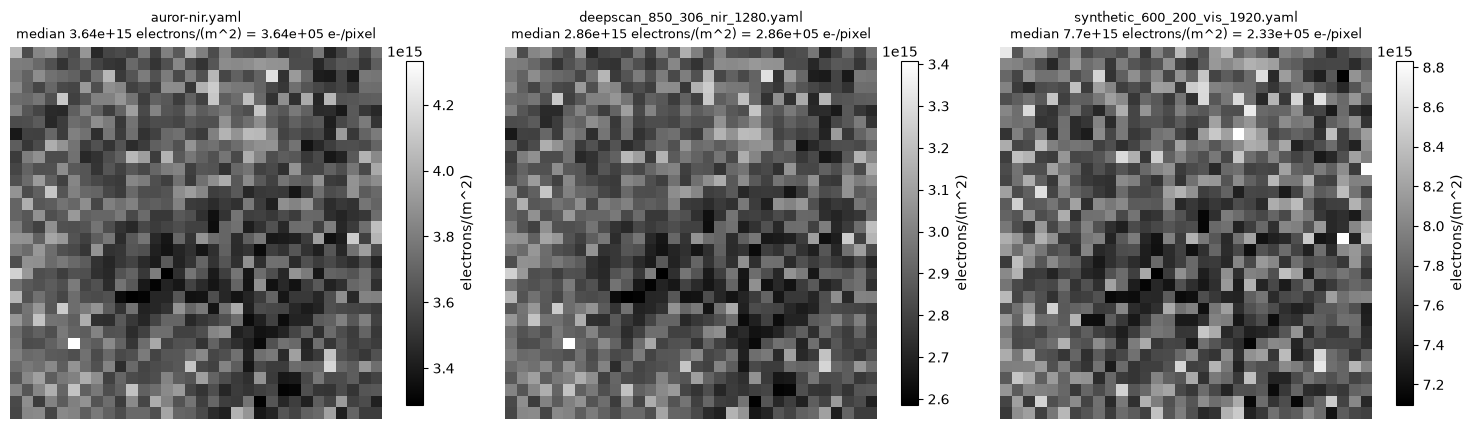

In [8]:
import time

t0 = time.perf_counter()
rendered = registry.run_sweep(submitted)
print(f"sweep {rendered.sweep_id} rendered in {time.perf_counter() - t0:4.1f} s")
for name, run in rendered.runs.items():
    print(f"   {name:48s} {run.state:9s} {run.result.image.relative_to(PROJECT) if run.result else run.errors}")
assert set(rendered.states.values()) == {"rendered"}


def load(name):
    run, spec = rendered.runs[name], sweep.runs[name]
    roi = spec["descriptor"]["settings"][0]["roi"]
    hdr = Path(f"{run.result.image}.hdr").read_text()
    units = next(l.split("=", 1)[1].strip() for l in hdr.splitlines() if l.startswith("data units"))
    img = np.fromfile(run.result.image, dtype="<f8").reshape(roi["Height"], roi["Width"])
    truth = np.fromfile(run.result.truth[0], dtype="<f8").reshape(roi["Height"], roi["Width"], 6)
    return img, truth, units


def entry_of(name):
    entry_id = sweep.runs[name]["descriptor"]["settings"][0]["entry_id"]
    return BY_ENTRY[entry_id]


fig, axes = plt.subplots(1, len(rendered.runs), figsize=(15, 4.6))
for ax, name in zip(axes, rendered.runs):
    img, truth, units = load(name)
    pitch_m = entry_of(name)["focal_planes"][0]["detector"]["SensorPixelWidth"] * 1e-6
    im = ax.imshow(img, cmap="gray")
    fig.colorbar(im, ax=ax, shrink=0.8, label=units)
    ax.set_title(f"{sweep.sensors[name]}\nmedian {np.median(img):.3g} {units} = {np.median(img) * pitch_m ** 2:.3g} e-/pixel",
                 fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

Per m² of focal plane the VIS image is about twice as bright as the `auror-nir` one (median 7.7e15
against 3.64e15). Its band is wider and its QE higher, which outweighs its slower optics (f/4 against
f/3.6). Per pixel it is darker, because a 5.5 µm pixel has 0.3 of the area of a 10 µm one. DeepScan has
`auror-nir`'s optics and band with the synthetic VisGaAs QE, and its image is 0.79 of `auror-nir`'s
(2.86e15), the QE at 0.85 µm.

## Ground sample distance from the geolocation truth

The template's `GeoLocation` truth gives the ECEF point each pixel's ray hit. The distance between
adjacent pixels on the ground, with the vertical component (terrain relief) projected out, should
be pitch ÷ focal length × range. The range is the platform's height from the run spec minus the
terrain height in the window, from the same truth.

In [9]:
print(f"{'run':48s} {'pitch/f x range':>16s} {'measured (median)':>18s} {'ratio':>7s}")
for name in rendered.runs:
    _, truth, _ = load(name)
    entry = entry_of(name)
    pitch_m = entry["focal_planes"][0]["detector"]["SensorPixelWidth"] * 1e-6
    focal_m = entry["optics"]["focal_length"] * 1e-3
    xyz = truth[..., 3:6]
    up = xyz / np.linalg.norm(xyz, axis=-1, keepdims=True)

    def horizontal(d, u):
        return np.linalg.norm(d - (d * u).sum(-1, keepdims=True) * u, axis=-1).ravel()

    spacing = np.concatenate([horizontal(np.diff(xyz, axis=0), up[:-1]), horizontal(np.diff(xyz, axis=1), up[:, :-1])])
    height = sweep.runs[name]["engine"]["motion"]["position"]["xyz"][2]     # scene frame, origin at 0 m
    predicted = pitch_m / focal_m * (height - np.median(truth[..., 2]))
    print(f"{name:48s} {predicted:14.2f} m {np.median(spacing):16.2f} m {np.median(spacing) / predicted:7.4f}")
    assert abs(np.median(spacing) / predicted - 1) < 0.01

run                                               pitch/f x range  measured (median)   ratio
sensor-sweep-tahoe--auror-nir                             17.97 m            17.98 m  1.0006
sensor-sweep-tahoe--deepscan_850_306_nir_1280             17.97 m            17.98 m  1.0006
sensor-sweep-tahoe--synthetic_600_200_vis_1920            15.12 m            15.19 m  1.0047


All three agree within 1 %. The library's GSD test (`tests/test_sensor_render.py`) checks the same thing
for all three sensors in a 16 × 16 window.

---
# What is synthetic and what is not

**Synthetic, invented for pipeline development (not vendor data, not measured):**

* all three spectral curves: `qe/synthetic_visgaas.csv`, `qe/synthetic_silicon.csv`,
  `optics/synthetic_vis_lens.csv` (`provenance: synthetic` in each file);
* the whole `synthetic_600_200_vis_1920` camera: aperture, focal length, 1920 × 1080 array, 5.5 µm
  pitch, band, readout;
* the DeepScan entry's QE, until the Teledyne SCION curve is imported.

**Carried from the received AUROR_ref tree:** the `auror-nir` optics (85 mm, 306 mm, 0.875
throughput), 10 µm pitch and gaussian 0.85 µm / 0.15 µm channel, the scene, atmosphere database,
weather, platform position, epoch and seed. The atmosphere database was built for western New York,
not Tahoe (CONOPS and Guide, section 9), so these electron counts are not Tahoe's.

**From vendor material:** DeepScan's detector block (Teledyne SCION family, 1280 × 1024, 10 µm
pitch, VisGaAs 0.3–1.7 µm). Its other values are copied from `auror-nir` and are listed in the
BACKLOG for confirmation.

**Measured here, on this DIRSIG install:** the generator's conventions against DIRSIG itself. These
are units, the native-channel factors, the window offset, the ground sample distance, and the
absolute electron count against an analytic Lambertian-plane value. That last check agrees to 1e-4
(`tests/test_absolute_radiometry.py`; CONOPS and Guide, section 9). It establishes that the sensor
chain is computed as stated. It does not make the synthetic curves real.